### Goal:
Generate two-band GeoTIFF that returns (Band 1) cloud class and (Band 2) confidence.

In [50]:
#Import necessary libraries

import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torch.utils.data.dataset import Dataset
from torchvision import transforms

Reminder: The CloudSEN12+ subset has the following
| Band Name     | Common Name     |
| ------------- | ------------- |
| B02  | Blue |
| B03  | Green |
| B04  | Red |
| B08  | NIR |
| CM1  | Expert-labeled Image |

- - -
### Preprocessing
The following code blocks will be for the preprocessing of our data. This involves the re-mapping of classes, the checking for invalid files, and first look of our tif files.
| Old Class     | New Classification     |
| ------------- | ------------- |
| Clear (0)  | Clear (0) |
| Thick Cloud (1) | Cloud (1) |
| Thin Cloud (2) | Cloud (1) |
| Shadow (2) | Shadow (2) |

In [34]:
# Redirectories for modified GeoTIFF files. We keep the original files to avoid accidental overwriting.
base_dirs = [
    "val_remap",
    "test_remap",
    "train_remap",
]

for base_dir in base_dirs:
    for root, dirs, files in os.walk(base_dir):
        for filename in files:
            if not filename.lower().endswith((".tif")):
                continue
            filepath = os.path.join(root, filename)

            # Read the GeoTIFF
            with rasterio.open(filepath) as src:
                data = src.read()
                profile = src.profile

            # Check that we have 5 bands
            if data.shape[0] != 5:
                print(f"  WARNING: expected 5 bands, got {data.shape[0]}")
                continue

            # Re-map the labelled band
            # Original:
            #   0 -> 0
            #   1 -> 1
            #   2 -> 1
            #   3 -> 2
            labels = data[4]

            labels[labels == 2] = 1
            labels[labels == 3] = 2

            # Write back to the same file
            with rasterio.open(filepath, "w", **profile) as dst:
                dst.write(data)

print("Re-mapping complete.")

Re-mapping complete.


In [35]:
# Check if masks were sucessfully re-mapped.
allowed_values = {0, 1, 2}

total_files = 0
bad_files = 0

for base_dir in base_dirs:
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if not file.lower().endswith(".tif"):
                continue

            total_files += 1
            filepath = os.path.join(root, file)

            with rasterio.open(filepath) as src:
                data = src.read()

            problems = []

            # Check shape
            if data.shape != (5, 509, 509):
                problems.append(f"wrong shape {data.shape}")

            else:
                # Check 5th band
                band5 = data[4]
                unique_values = set(np.unique(band5))
                invalid_values = unique_values - allowed_values

                if invalid_values:
                    problems.append(
                        f"invalid band 5 values: {sorted(invalid_values)}"
                    )

            if problems:
                bad_files += 1
                print(f"❌ {filepath}")
                for problem in problems:
                    print(f"   {problem}")

print("\n--------------------")
print(f"Total .tif files: {total_files}")
print(f"Bad files:         {bad_files}")
print(f"Good files:        {total_files - bad_files}")

if bad_files == 0:
    print("✅ All files passed!")


--------------------
Total .tif files: 5755
Bad files:         0
Good files:        5755
✅ All files passed!


In [ ]:
# Choosing arbitrary files to check contents and plot
visualization_files = ["train_remap/ROI_0748/20200318T141731_20200318T141731_T20MRB.tif",
             "val_remap/ROI_0009/20190513T180929_20190513T181344_T12SWH.tif",
             "test_remap/ROI_0001/20190212T142031_20190212T143214_T19FDF.tif"]

with rasterio.open(visualization_files[0]) as src:
    image = src.read()  # (bands, height, width)

red = image[2]   #  Band 4
green = image[1] #  Band 3
blue = image[0]  # Band 2

for name, band in zip(
    ["Red (B4)", "Green (B3)", "Blue (B2)"],
    [image[2], image[1], image[0]]
):
    print(
        name,
        "min =", np.min(band),
        "max =", np.max(band),
        "mean =", np.mean(band),
        "P2 =", np.percentile(band, 2),
        "P98 =", np.percentile(band, 98)
    )

Red (B4) min = 1305 max = 5938 mean = 2637.1536392093594 P2 = 1729.0 P98 = 3641.0
Green (B3) min = 1079 max = 5677 mean = 2442.800050949317 P2 = 1547.0 P98 = 3443.0
Blue (B2) min = 803 max = 5676 mean = 2407.7390352824023 P2 = 1371.0 P98 = 3483.0


- - - 
##### We normalize the output of the bands, so that we have a better RGB composite. We also display the accompanying cloud mask, just to see what we are dealing with.

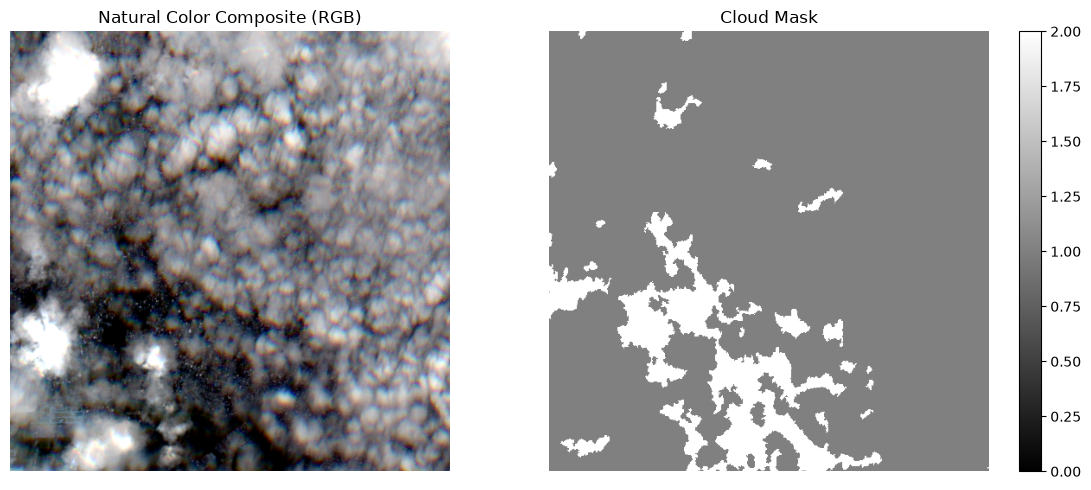

In [31]:
red = image[2].astype(np.float32)
green = image[1].astype(np.float32)
blue = image[0].astype(np.float32)

rgb = np.stack([red, green, blue], axis=-1)

rgb_normalized = np.zeros_like(rgb)

for i in range(3):
    # We limit it to the 2nd and 98th percentile to avoid outliers affecting the visualization,
    vmin = np.percentile(rgb[:, :, i], 2)
    vmax = np.percentile(rgb[:, :, i], 98)

    rgb_normalized[:, :, i] = np.clip(
        (rgb[:, :, i] - vmin) / (vmax - vmin),
        0,
        1
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Natural Color Composite (RGB)
ax[0].imshow(rgb_normalized)
ax[0].set_title("Natural Color Composite (RGB)")
ax[0].axis("off")

# Cloud Mask from labelled band
im = ax[1].imshow(image[4], cmap="gray", vmin=0, vmax=2)
ax[1].set_title("Cloud Mask")
ax[1].axis("off")
fig.colorbar(im, ax=ax[1])

plt.tight_layout()
plt.show()

- - -
### Implementing our semantic segmentation
The following code blocks will be for implementing our neural network. For this project, I will opt to use U-net architecture, a modification of the fully convolutional networks. A key difference being the skip-connections, allowing

The next code block initializes the neural network, specifically its convolution, downsampling and upsampling.

In [44]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Make x1 the same spatial size as the skip connection
        x1 = F.interpolate(
            x1,
            size=x2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

Using the classes from the previous code block, we will implement the UNet.

In [45]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        down1, p1 = self.down_convolution_1(x)
        down2, p2 = self.down_convolution_2(p1)
        down3, p3 = self.down_convolution_3(p2)
        down4, p4 = self.down_convolution_4(p3)

        bottleneck = self.bottle_neck(p4)

        up1 = self.up_convolution_1(bottleneck, down4)
        up2 = self.up_convolution_2(up1, down3)
        up3 = self.up_convolution_3(up2, down2)
        up4 = self.up_convolution_4(up3, down1)

        return self.out(up4)

Debugging to see if DoubleConv works, and if the output of the UNet has the same dimensions as our input image.

In [ ]:
if __name__ == "__main__":
    double_conv = DoubleConv(256, 256)
    #print(double_conv)

    # Batch size of 1, 4 channels, 509x509 image to simulate our input data from CloudSEN12+
    input_image = torch.randn(1, 4, 509, 509)  
    # The model is taking in 4 input channels, and outputting 3 classes.
    model = UNet(4, 3)
    output = model(input_image)
    print(output.shape)

DoubleConv(
  (double_conv): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
)
torch.Size([1, 3, 509, 509])


- - -

Training